# Building a GPT

In [1]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
path="./tinyshakespeare/input.txt"

In [2]:
with open(path,'r', encoding='utf-8') as f:
    text=f.read()

In [3]:
print("length of dataset in chars",len(text))

length of dataset in chars 1115394


In [4]:
print(text[:1000]) #first 1k chars

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [5]:
# all the unique chars
chars=sorted(list(set(text)))
vocab_size=len(chars)
print("".join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [6]:
# mapping from chars to integers
stoi={ch:i for i, ch in enumerate(chars)}
itos={i:ch for i, ch in enumerate(chars)}
stoi

{'\n': 0,
 ' ': 1,
 '!': 2,
 '$': 3,
 '&': 4,
 "'": 5,
 ',': 6,
 '-': 7,
 '.': 8,
 '3': 9,
 ':': 10,
 ';': 11,
 '?': 12,
 'A': 13,
 'B': 14,
 'C': 15,
 'D': 16,
 'E': 17,
 'F': 18,
 'G': 19,
 'H': 20,
 'I': 21,
 'J': 22,
 'K': 23,
 'L': 24,
 'M': 25,
 'N': 26,
 'O': 27,
 'P': 28,
 'Q': 29,
 'R': 30,
 'S': 31,
 'T': 32,
 'U': 33,
 'V': 34,
 'W': 35,
 'X': 36,
 'Y': 37,
 'Z': 38,
 'a': 39,
 'b': 40,
 'c': 41,
 'd': 42,
 'e': 43,
 'f': 44,
 'g': 45,
 'h': 46,
 'i': 47,
 'j': 48,
 'k': 49,
 'l': 50,
 'm': 51,
 'n': 52,
 'o': 53,
 'p': 54,
 'q': 55,
 'r': 56,
 's': 57,
 't': 58,
 'u': 59,
 'v': 60,
 'w': 61,
 'x': 62,
 'y': 63,
 'z': 64}

In [7]:
itos

{0: '\n',
 1: ' ',
 2: '!',
 3: '$',
 4: '&',
 5: "'",
 6: ',',
 7: '-',
 8: '.',
 9: '3',
 10: ':',
 11: ';',
 12: '?',
 13: 'A',
 14: 'B',
 15: 'C',
 16: 'D',
 17: 'E',
 18: 'F',
 19: 'G',
 20: 'H',
 21: 'I',
 22: 'J',
 23: 'K',
 24: 'L',
 25: 'M',
 26: 'N',
 27: 'O',
 28: 'P',
 29: 'Q',
 30: 'R',
 31: 'S',
 32: 'T',
 33: 'U',
 34: 'V',
 35: 'W',
 36: 'X',
 37: 'Y',
 38: 'Z',
 39: 'a',
 40: 'b',
 41: 'c',
 42: 'd',
 43: 'e',
 44: 'f',
 45: 'g',
 46: 'h',
 47: 'i',
 48: 'j',
 49: 'k',
 50: 'l',
 51: 'm',
 52: 'n',
 53: 'o',
 54: 'p',
 55: 'q',
 56: 'r',
 57: 's',
 58: 't',
 59: 'u',
 60: 'v',
 61: 'w',
 62: 'x',
 63: 'y',
 64: 'z'}

### Encoder
takes a string, outputs a list of integers

In [8]:
encode= lambda s: [stoi[c] for c in s] 

### Decoder
takes a list of integers, outputs a string

In [9]:
decode= lambda l: "".join([itos[i] for i in l])

In [10]:
print(encode("hi my name is jyoti"))

[46, 47, 1, 51, 63, 1, 52, 39, 51, 43, 1, 47, 57, 1, 48, 63, 53, 58, 47]


In [11]:
print(decode([46, 47, 1, 51, 63, 1, 52, 39, 51, 43, 1, 47, 57, 1, 48, 63, 53, 58, 47]))

hi my name is jyoti


* Google uses [Sentencepiece](https://github.com/google/sentencepiece)- subword tokenizer
* GPT uses [tiktoken](https://github.com/openai/tiktoken) - BPE encoding

In [12]:
import torch
data=torch.tensor(encode(text), dtype=torch.long)

In [13]:
print(data.shape, data.dtype)

torch.Size([1115394]) torch.int64


In [14]:
print(data[:1000])

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
        47, 59, 57,  1, 47, 57,  1, 41, 

### Train & Validation Split

In [15]:
n=int(0.9*len(data))  #90% data used for training, 10% for validation

In [16]:
train_data=data[:n]
val_data=data[n:]

We don't train a transformer on entire text once. It will be computationally expensive. 
When we train transformer, we only work with chunks of dataset. We randomly sample chunks and train on them. We're calling these chunks as block_size


In [17]:
block_size=8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

When we sample a chunk of data like this, it has multiple examples packed because all these chars follow each other. We train it simulateneously to make predictions at each step

In [18]:
x=train_data[:block_size]
y=train_data[1:block_size+1]
for t in range(block_size):
    context=x[:t+1]
    target=y[t]
    print(f"when input is {context} the target is: {target}")

when input is tensor([18]) the target is: 47
when input is tensor([18, 47]) the target is: 56
when input is tensor([18, 47, 56]) the target is: 57
when input is tensor([18, 47, 56, 57]) the target is: 58
when input is tensor([18, 47, 56, 57, 58]) the target is: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target is: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target is: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target is: 58


We need to take care of batch dimension. We'll have many batches of multiple pieces of text all stacked in one tensor. We'll do parallel processing of data, multiple chunks being processed independently at the same time.

In [19]:
torch.manual_seed(1337)
batch_size=4 # number of independent sequences we'll process in parallel
block_size=8 # maximum context length for predictions

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data= train_data if split=='train' else val_data
    ix=torch.randint(len(data)-block_size,(batch_size, )) 
    # batch size number of random offsets
    # ix will be 4 random numbers between 0 and len(data)-block_size
    x=torch.stack([data[i:i+block_size] for i in ix]) 
    #generating chunks for every  i in ix, we stack them up as rows
    y=torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x,y

In [20]:
xb, yb=get_batch("train")
print("inputs:")
print(xb.shape)
print(xb)
# xb will be our input to the transformer

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])


In [21]:
print("targets:")
print(yb.shape)
print(yb)

targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])


In [22]:
print('-----')
for b in range(batch_size): #batch dimension
    for t in range(block_size): #time dimension
        context=xb[b, :t+1]
        target=yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

-----
when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53, 56, 1, 58, 46] the target: 39
when input is [44, 53, 56, 1, 58, 46, 39] the target: 58
when input is [44, 53, 56, 1, 58, 46, 39, 58] the target: 1
when input is [52] the target: 58
when input is [52, 58] the target: 1
when input is [52, 58, 1] the target: 58
when input is [52, 58, 1, 58] the target: 46
when input is [52, 58, 1, 58, 46] the target: 39
when input is [52, 58, 1, 58, 46, 39]

These are 32 independent examples packed in a tensor

We'll use simplest language model i.e. Bigram language model

In [23]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

In [24]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table=nn.Embedding(vocab_size, vocab_size) 
        # 24 will go and pluck out 24th row, similarly 48th will go and pluck out 48th row 
        # and then arrange them as B,T,C 

    def forward(self, idx, targets=None):
        # idx and targets are both (B, T) tensor of integers
        logits=self.token_embedding_table(idx) # (B,T,C)
        if targets is None:
            loss=None
        else: 
            B, T, C=logits.shape
            logits=logits.view(B*T, C) 
            targets=targets.view(B*T)
            loss=F.cross_entropy(logits, targets)
        return logits, loss
    
    

In [25]:
model=BigramLanguageModel(vocab_size)
logits, loss=model(xb, yb)
print(logits.shape)
print(loss)
# we expect loss -ln(1/65)~ 4.7 something

torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)


## Generation 

In [26]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table=nn.Embedding(vocab_size, vocab_size) 
        # 24 will go and pluck out 24th row, similarly 48th will go and pluck out 48th row 
        # and then arrange them as B,T,C 

    def forward(self, idx, targets=None):
        # idx and targets are both (B, T) tensor of integers
        logits=self.token_embedding_table(idx) # (B,T,C)
        if targets is None:
            loss=None
        else: 
            B, T, C=logits.shape
            logits=logits.view(B*T, C) 
            targets=targets.view(B*T)
            loss=F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B,T) array of indices in the current context
        # job of generator is to take (B,T) and generate (B,T)+1, (B,T)+2 and so on 
        # as many max new tokens
        for _ in range(max_new_tokens):
            #crop idx to the last block_size tokens
            idx_cond=idx[:, -block_size:]
            #get the predictions
            logits, loss=self(idx_cond)
            # focus only on the last time step
            logits=logits[:, -1,:] # (B,C)
            # apply softmax to get probabilities
            probs=F.softmax(logits, dim=-1) #(B,C)
            # sample from the distribution
            idx_next=torch.multinomial(probs, num_samples=1) # (B,1)
            # append sampled index to the running sequence
            idx=torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
            
    
    

In [27]:
m=BigramLanguageModel(vocab_size)
logits, loss=m(xb, yb)
print(logits.shape)
print(loss)

torch.Size([32, 65])
tensor(4.6630, grad_fn=<NllLossBackward0>)


In [28]:
print(decode(m.generate(idx=torch.zeros((1,1), dtype=torch.long),max_new_tokens=100)[0].tolist()))


v?vqKGh
txYXcDRSW&jxn;P Kuvbv
Bl:KuMWi;JYlFahlK3u.M,QV;oky3wcxoYPQpbpb
r3Nc 'MQHQ uOfxoxwXIvSE-$&a$K


In [29]:
# create a PyTorch optimizer
optimizer=torch.optim.AdamW(m.parameters(), lr=1e-3)

In [30]:
batch_size=32
for steps in range(10000):
    # sample a batch of data
    xb,yb=get_batch("train")
    # evaluate the loss
    logits, loss=m(xb,yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
print(loss.item())
    

2.3781542778015137


In [31]:
print(decode(m.generate(idx=torch.zeros((1,1), dtype=torch.long),max_new_tokens=300)[0].tolist()))


Yorowathit comoue int at se,
Crrtr mou oneny grom be;
mva-BUGR in y llican fer wid.


MIt
O:


OLAfobont aiee;
Anlone aves ve t fo mnd h ve g ay' th,
He heng-piur Yom: nee
MPrny
haiolersceangen
Bur we harplo ho pleich thalk wiriteamithe in, ow
Jute mjeneno hard SHO:

Tht bith;

An: se'
Ox, sodout ws


We're just looking at last token, now we want the tokens to talk to each other.

## The mathematical trick in self-attention

In [32]:
import torch
torch.manual_seed(1337)
B,T,C=4,8,2 # batch, time , channels
X=torch.randn(B,T,C)
X.shape

torch.Size([4, 8, 2])

In [33]:
# we want x[b,t] = mean_{i<=t} x[b,i]

xbow=torch.zeros((B,T,C)) 
for b in range(B): #iterating over all batch dimensions
    for t in range(T): # iterating over time
        xprev=X[b,:t+1] #(t,C) # previous chunk tokens
        xbow[b,t]=torch.mean(xprev, 0) # mean 
        

In [34]:
X[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [35]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [36]:
torch.manual_seed(42)
a=torch.ones(3,3)
b=torch.randint(0,10,(3,2)).float()
c=a@b
print("a=")
print(a)
print("----\nb=")
print(b)
print("----\nc=")
print(c)


a=
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
----
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
----
c=
tensor([[14., 16.],
        [14., 16.],
        [14., 16.]])


In [37]:
torch.manual_seed(42)
a=torch.tril(torch.ones(3,3))
#tril(): Returns the lower triangular part of the matrix (2-D tensor) or batch of matrices input, the other elements of the result tensor out are set to 0.
b=torch.randint(0,10,(3,2)).float()
c=a@b
print("a=")
print(a)
print("----\nb=")
print(b)
print("----\nc=")
print(c)


a=
tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])
----
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
----
c=
tensor([[ 2.,  7.],
        [ 8., 11.],
        [14., 16.]])


In [38]:
torch.manual_seed(42)
a=torch.tril(torch.ones(3,3))
a=a/torch.sum(a,1,keepdim=True)
b=torch.randint(0,10,(3,2)).float()
c=a@b
print("a=")
print(a)
print("----\nb=")
print(b)
print("----\nc=")
print(c)


a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
----
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
----
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


## using matrix multiply

In [39]:
torch.manual_seed(1337)
B,T,C=4,8,2 #batch, time, channels
x=torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [40]:
# we want x[b,t] = mean_{i<=t} x[b,i]

xbow=torch.zeros((B,T,C)) 
for b in range(B): #iterating over all batch dimensions
    for t in range(T): # iterating over time
        xprev=X[b,:t+1] #(t,C) # previous chunk tokens
        xbow[b,t]=torch.mean(xprev, 0) # mean 
         

In [41]:
wei=torch.tril(torch.ones(T,T)) #weighted aggregration
wei=wei/wei.sum(1, keepdim=True)
xbow2=wei @  x #(T, T) @ (B, T, C) 

In [42]:
torch.allclose(xbow, xbow2)

True

In [43]:
torch.tril(torch.ones(3, 3))

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

In [44]:
xbow, xbow2

(tensor([[[ 0.1808, -0.0700],
          [-0.0894, -0.4926],
          [ 0.1490, -0.3199],
          [ 0.3504, -0.2238],
          [ 0.3525,  0.0545],
          [ 0.0688, -0.0396],
          [ 0.0927, -0.0682],
          [-0.0341,  0.1332]],
 
         [[ 1.3488, -0.1396],
          [ 0.8173,  0.4127],
          [-0.1342,  0.4395],
          [ 0.2711,  0.4774],
          [ 0.2421,  0.0694],
          [ 0.0084,  0.0020],
          [ 0.0712, -0.1128],
          [ 0.2527,  0.2149]],
 
         [[-0.6631, -0.2513],
          [ 0.1735, -0.0649],
          [ 0.1685,  0.3348],
          [-0.1621,  0.1765],
          [-0.2312, -0.0436],
          [-0.1015, -0.2855],
          [-0.2593, -0.1630],
          [-0.3015, -0.2293]],
 
         [[ 1.6455, -0.8030],
          [ 1.4985, -0.5395],
          [ 0.4954,  0.3420],
          [ 1.0623, -0.1802],
          [ 1.1401, -0.4462],
          [ 1.0870, -0.4071],
          [ 1.0430, -0.1299],
          [ 1.1138, -0.1641]]]),
 tensor([[[ 0.1808, -0.0700]

## Adding Softmax

In [45]:
tril=torch.tril(torch.ones(T,T))
wei=torch.zeros((T,T))
wei=wei.masked_fill(tril==0, float('-inf'))
wei=F.softmax(wei, dim=-1) # we apply softmax function
xbow3=wei @ x
torch.allclose(xbow, xbow3)

True

In [46]:
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [47]:
torch.manual_seed(42)
a=torch.tril(torch.ones(3,3))
a=a/torch.sum(a,1,keepdim=True)
b=torch.randint(0,10,(3,2)).float()
c=a@b
print("a=")


a=


### Self Attention

In [48]:
torch.manual_seed(1337)
B,T,C=4,8,32 #batch, time, channels
x=torch.randn(B,T,C)
tril=torch.tril(torch.ones(T,T))
wei=torch.zeros((T,T))
wei=wei.masked_fill(tril==0, float('-inf'))
wei=F.softmax(wei, dim=-1)
out=wei @ x
out.shape


torch.Size([4, 8, 32])

In [49]:
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

### Implementing single head of self attention

In [52]:
# every single token at each position will emit two vectors, query & key
# query is what i am looking for
# key if what do I contain
# dot product between key & query and that dot product will become wei
torch.manual_seed(1337)
B,T,C=4,8,32 #batch, time, channels
x=torch.randn(B,T,C)

head_size=16
key=nn.Linear(C, head_size, bias=False)
query=nn.Linear(C, head_size, bias=False)
value=nn.Linear(C, head_size, bias=False)
k=key(x) # (B, T, 16)
q= query(x) # (B, T, 16)
wei= q @ k.transpose(-2,-1) # transposing last two dim
# (B,T,16) @ (B,16, T)---> (B, T , T)
# let's see a single head perform self-attention
v=value(x)
tril=torch.tril(torch.ones(T,T))
wei=wei.masked_fill(tril==0, float('-inf'))
wei=F.softmax(wei, dim=-1)
# out=wei @ x
out=wei @ v
out.shape


torch.Size([4, 8, 16])

In [53]:
wei

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
         [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
         [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
         [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1687, 0.8313, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2477, 0.0514, 0.7008, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4410, 0.0957, 0.3747, 0.0887, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0069, 0.0456, 0.0300, 0.7748, 0.1427, 0.0000, 0.0000, 0.0000],
         [0.0660, 0.089

Notes:
- Attention is a communication mechanism. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across the batch dimension is ofcourse processed completely independently and never "talk" to each other.
- In an "encoder" attention block just delete the single line that does masking `tril`, allowing all tokens to communicate. here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modelling.
- 'self-attention' just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source(eg. an encoder module)
- "Scaled" attention additional divides wei by 1/sqrt(head_size). This makes it so when input Q, K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much.

In [54]:
k=torch.randn(B, T, head_size)
q=torch.randn(B, T, head_size)
wei=q @ k.transpose(-2,-1) # *head_size**-0.5
k.var()

tensor(1.0449)

In [55]:
q.var()

tensor(1.0700)

In [56]:
wei.var() #order of headsize

tensor(17.4690)

In [57]:
k=torch.randn(B, T, head_size)
q=torch.randn(B, T, head_size)
wei=q @ k.transpose(-2,-1)*head_size**-0.5
k.var()


tensor(0.9006)

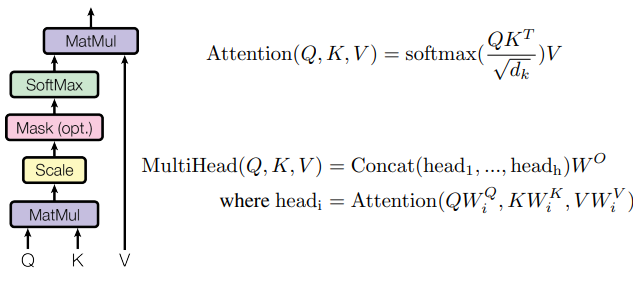

In [58]:
wei.var() # variance is nearly 1 when we multiply by 1/ root dk

tensor(0.9957)